In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import time
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [ ]:
# MNIST
(mnist_x_train, mnist_y_train), (mnist_x_test, mnist_y_test) = tf.keras.datasets.mnist.load_data()
mnist_x_train = mnist_x_train / 255.0
mnist_x_test = mnist_x_test / 255.0
mnist_x_train = mnist_x_train[..., np.newaxis]
mnist_x_test = mnist_x_test[..., np.newaxis]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# CIFAR-10
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = tf.keras.datasets.cifar10.load_data()
cifar_x_train = cifar_x_train / 255.0
cifar_x_test = cifar_x_test / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
def train_model(model, x_train, y_train, x_test, y_test, epochs=10):
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])

    start_time = time.time()
    history = model.fit(x_train, y_train, epochs=epochs,
                        validation_data=(x_test, y_test), verbose=1)
    end_time = time.time()

    print("Training Time (seconds):", round(end_time - start_time, 2))
    return history

(a) Varying Convolution Layers

In [ ]:
def cnn_shallow(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [ ]:
model_a1 = cnn_shallow((28,28,1), 10)
history_a1 = train_model(model_a1, mnist_x_train, mnist_y_train, mnist_x_test, mnist_y_test)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9151 - loss: 0.3021 - val_accuracy: 0.9802 - val_loss: 0.0597
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9844 - loss: 0.0525 - val_accuracy: 0.9835 - val_loss: 0.0475
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9899 - loss: 0.0315 - val_accuracy: 0.9836 - val_loss: 0.0474
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9938 - loss: 0.0195 - val_accuracy: 0.9834 - val_loss: 0.0494
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9963 - loss: 0.0123 - val_accuracy: 0.9867 - val_loss: 0.0427
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9975 - loss: 0.0087 - val_accuracy: 0.9860 - val_loss: 0.0524
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9975 - loss: 0.0077 - val_accuracy: 0.9873 - val_loss: 0.0475
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9985 - loss: 0.0051 -

In [ ]:
def cnn_deep(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [ ]:
model_a2 = cnn_deep((28,28,1), 10)
history_a2 = train_model(model_a2, mnist_x_train, mnist_y_train, mnist_x_test, mnist_y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9323 - loss: 0.2190 - val_accuracy: 0.9870 - val_loss: 0.0407
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9885 - loss: 0.0349 - val_accuracy: 0.9897 - val_loss: 0.0330
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9931 - loss: 0.0212 - val_accuracy: 0.9876 - val_loss: 0.0359
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9960 - loss: 0.0138 - val_accuracy: 0.9896 - val_loss: 0.0338
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9962 - loss: 0.0116 - val_accuracy: 0.9912 - val_loss: 0.0305
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9970 - loss: 0.0090 - val_accuracy: 0.9933 - val_loss: 0.0251
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9976 - loss: 0.0070 - val_accuracy: 0.9921 - val_loss: 0.0273
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9977 - loss: 0.0067 -

(b) Padding + Batch Normalization

In [ ]:
def cnn_padding_bn(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

In [ ]:
model_b = cnn_padding_bn((28,28,1), 10)
history_b = train_model(model_b, mnist_x_train, mnist_y_train, mnist_x_test, mnist_y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.9235 - loss: 0.3616 - val_accuracy: 0.9753 - val_loss: 0.0797
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9840 - loss: 0.0547 - val_accuracy: 0.9832 - val_loss: 0.0635
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9899 - loss: 0.0348 - val_accuracy: 0.9850 - val_loss: 0.0589
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9906 - loss: 0.0318 - val_accuracy: 0.9864 - val_loss: 0.0578
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9940 - loss: 0.0190 - val_accuracy: 0.9829 - val_loss: 0.0783
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9947 - loss: 0.0174 - val_accuracy: 0.9833 - val_loss: 0.0710
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9957 - loss: 0.0143 - val_accuracy: 0.9864 - val_loss: 0.0597
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9968 - loss: 0.0106 -

(c) Hyperparameter Tuning

In [ ]:
def cnn_hyperparams(input_shape, num_classes, lr=0.001):
    model = models.Sequential([
        layers.Conv2D(64, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
model_c = cnn_hyperparams((28,28,1), 10, lr=0.0005)
history_c = model_c.fit(mnist_x_train, mnist_y_train, epochs=10,
                        validation_data=(mnist_x_test, mnist_y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9135 - loss: 0.2978 - val_accuracy: 0.9799 - val_loss: 0.0636
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9850 - loss: 0.0500 - val_accuracy: 0.9859 - val_loss: 0.0418
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9909 - loss: 0.0295 - val_accuracy: 0.9835 - val_loss: 0.0534
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9944 - loss: 0.0185 - val_accuracy: 0.9859 - val_loss: 0.0426
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9967 - loss: 0.0111 - val_accuracy: 0.9881 - val_loss: 0.0406
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9978 - loss: 0.0074 - val_accuracy: 0.9882 - val_loss: 0.0383
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9983 - loss: 0.0061 - val_accuracy: 0.9863 - val_loss: 0.0467
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9983 - loss: 0.0051 -

(d) Regularization & Dropout

i) Base Model

In [ ]:
def base_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model



ii) L1 Regularization


In [ ]:
def l1_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu',
                      kernel_regularizer=regularizers.l1(0.001),
                      input_shape=input_shape),
        layers.Flatten(),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l1(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

iii) L2 Regularization

In [ ]:
def l2_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu',
                      kernel_regularizer=regularizers.l2(0.001),
                      input_shape=input_shape),
        layers.Flatten(),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

iv) Dropout

In [ ]:
def dropout_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

v) L2 + Dropout

In [ ]:
def l2_dropout_model(input_shape, num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu',
                      kernel_regularizer=regularizers.l2(0.001),
                      input_shape=input_shape),
        layers.Dropout(0.3),
        layers.Flatten(),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

CPU vs GPU Time

In [ ]:
with tf.device('/CPU:0'):
    model_cpu = base_model((28,28,1), 10)
    train_model(model_cpu, mnist_x_train, mnist_y_train, mnist_x_test, mnist_y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 68s 35ms/step - accuracy: 0.9239 - loss: 0.2501 - val_accuracy: 0.9810 - val_loss: 0.0613
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9873 - loss: 0.0426 - val_accuracy: 0.9843 - val_loss: 0.0502
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9942 - loss: 0.0189 - val_accuracy: 0.9836 - val_loss: 0.0543
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 33ms/step - accuracy: 0.9946 - loss: 0.0160 - val_accuracy: 0.9829 - val_loss: 0.0646
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 35ms/step - accuracy: 0.9970 - loss: 0.0088 - val_accuracy: 0.9838 - val_loss: 0.0609
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9978 - loss: 0.0071 - val_accuracy: 0.9840 - val_loss: 0.0651
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 33ms/step - accuracy: 0.9987 - loss: 0.0040 - val_accuracy: 0.9829 - val_loss: 0.0764
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 33ms/step - accuracy: 0.9983 -

GPU

In [ ]:
with tf.device('/GPU:0'):
    model_gpu = base_model((28,28,1), 10)
    train_model(model_gpu, mnist_x_train, mnist_y_train, mnist_x_test, mnist_y_test)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9226 - loss: 0.2588 - val_accuracy: 0.9798 - val_loss: 0.0663
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9871 - loss: 0.0439 - val_accuracy: 0.9835 - val_loss: 0.0510
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.9930 - loss: 0.0230 - val_accuracy: 0.9801 - val_loss: 0.0613
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9961 - loss: 0.0125 - val_accuracy: 0.9833 - val_loss: 0.0610
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9970 - loss: 0.0089 - val_accuracy: 0.9843 - val_loss: 0.0590
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9985 - loss: 0.0057 - val_accuracy: 0.9838 - val_loss: 0.0758
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9981 - loss: 0.0057 - val_accuracy: 0.9822 - val_loss: 0.0795
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9982 - loss: 0.0050 -

Plot Accuracy vs Epochs

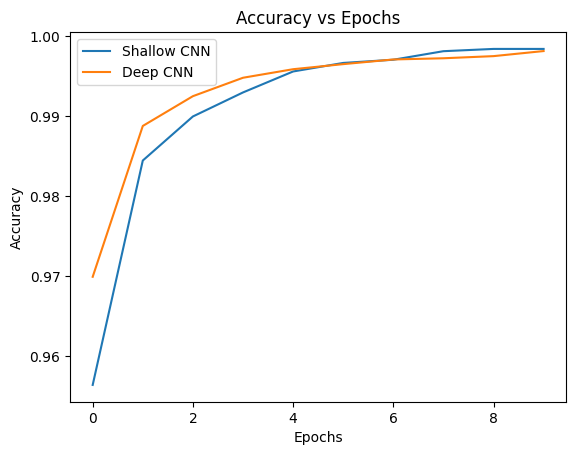

In [ ]:
plt.plot(history_a1.history['accuracy'], label='Shallow CNN')
plt.plot(history_a2.history['accuracy'], label='Deep CNN')
plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epochs")
plt.show()